# Garbage Reports — Forecasting Model Tests

This notebook is intentionally focused on **model evaluation**, not exploratory plots.

The default task is **rolling one-day-ahead forecasting**:
- when forecasting day *t*, values from earlier days are assumed to be known;
- lagged predictors therefore use only past observations;
- evaluation uses expanding training windows and future test years.

The current benchmark is to improve on simple baselines while keeping performance stable across years.


## One-time dependency

This version uses the `holidays` package for Greek public holidays.

If you do not already have it installed, run the following once in Jupyter:

```python
%pip install holidays
```

Then restart the kernel if Jupyter asks you to.


In [1]:
import warnings

import pandas as pd
import holidays
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf

from scipy.stats import chi2
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Data configuration and preparation

In [2]:
PATH = r"data/requests.csv"

ISSUE_TYPE = "garbage"
START_YEAR = 2020
END_YEAR = 2025

df = pd.read_csv(PATH)
df["reported"] = pd.to_datetime(df["reported"], errors="coerce")

df = (
    df.loc[
        (df["issue"] == ISSUE_TYPE)
        & (df["reported"].dt.year >= START_YEAR)
        & (df["reported"].dt.year <= END_YEAR)
    ]
    .dropna(subset=["reported"])
    .sort_values("reported")
    .copy()
)

daily_counts = (
    df.set_index("reported")
      .resample("D")
      .size()
)

daily_df = daily_counts.reset_index(name="reports")
daily_df["weekday"] = daily_df["reported"].dt.day_name()
daily_df["month"] = daily_df["reported"].dt.month

# Greek public-holiday features.
# is_holiday is used by the model; holiday_name is only for inspection.
greek_holidays = holidays.country_holidays(
    "GR",
    years=range(START_YEAR, END_YEAR + 1)
)

report_dates = daily_df["reported"].dt.date
daily_df["is_holiday"] = report_dates.isin(greek_holidays)
daily_df["holiday_name"] = report_dates.apply(
    lambda date: greek_holidays.get(date, "")
)

# Scale the time trend to years rather than raw day numbers.
# This is numerically friendlier for the Negative Binomial optimizer.
daily_df["trend_years"] = (
    (daily_df["reported"] - daily_df["reported"].min()).dt.days / 365.25
)

# Lag / recent-history features.
# Every feature is shifted, so today's report count is never used to predict today.
daily_df["lag1"] = daily_df["reports"].shift(1)
daily_df["lag7"] = daily_df["reports"].shift(7)
daily_df["recent3_avg"] = daily_df["reports"].shift(1).rolling(3).mean()
daily_df["rolling7_avg"] = daily_df["reports"].shift(1).rolling(7).mean()
daily_df["same_weekday_4wk_avg"] = (
    daily_df["reports"].shift(7)
    + daily_df["reports"].shift(14)
    + daily_df["reports"].shift(21)
    + daily_df["reports"].shift(28)
) / 4

print(f"Daily observations: {len(daily_df):,}")
print(f"Date range: {daily_df['reported'].min().date()} -> {daily_df['reported'].max().date()}")

print(f"Greek public-holiday dates flagged: {daily_df['is_holiday'].sum()}")
display(
    daily_df.loc[
        daily_df["is_holiday"],
        ["reported", "reports", "holiday_name"]
    ].head(20)
)


Daily observations: 2,191
Date range: 2020-01-02 -> 2025-12-31
Greek public-holiday dates flagged: 73


,reported,reports,holiday_name
4,2020-01-06,1,Θεοφάνεια
60,2020-03-02,0,Καθαρά Δευτέρα
83,2020-03-25,10,Εικοστή Πέμπτη Μαρτίου
106,2020-04-17,7,Μεγάλη Παρασκευή
109,2020-04-20,11,Δευτέρα του Πάσχα
120,2020-05-01,9,Εργατική Πρωτομαγιά
158,2020-06-08,6,Δευτέρα του Αγίου Πνεύματος
226,2020-08-15,6,Κοίμηση της Θεοτόκου
300,2020-10-28,1,Ημέρα του Όχι
358,2020-12-25,13,Χριστούγεννα


## 2. Poisson overdispersion check

The raw variance/mean ratio is only a rough first look. The more relevant check is whether overdispersion remains **after** trend, weekday and month are included.

A Pearson dispersion substantially above 1 supports using Negative Binomial rather than ordinary Poisson regression.


In [3]:
poisson_train = daily_df[daily_df["reported"].dt.year <= 2024].copy()

poisson_model = smf.glm(
    "reports ~ trend_years + C(weekday) + C(month)",
    data=poisson_train,
    family=sm.families.Poisson()
).fit()

raw_mean = poisson_train["reports"].mean()
raw_var = poisson_train["reports"].var()

pearson_dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
deviance_dispersion = poisson_model.deviance / poisson_model.df_resid
pearson_p = chi2.sf(poisson_model.pearson_chi2, poisson_model.df_resid)

print(f"Raw mean:                 {raw_mean:.3f}")
print(f"Raw variance:             {raw_var:.3f}")
print(f"Raw variance / mean:      {raw_var / raw_mean:.3f}")
print()
print(f"Pearson dispersion:       {pearson_dispersion:.3f}")
print(f"Deviance / df:            {deviance_dispersion:.3f}")
print(f"Pearson dispersion p-val: {pearson_p:.3e}")

Raw mean:                 19.427
Raw variance:             168.911
Raw variance / mean:      8.695

Pearson dispersion:       3.169
Deviance / df:            3.415
Pearson dispersion p-val: 0.000e+00


## 3. Choose what to test

Change **only `MODEL_TO_TEST`** and rerun this cell plus the next one.

Available choices:

- `"all"` — compare every model below.
- `"baselines"` — compare only simple baselines.
- `"nb_base"` — Negative Binomial: trend + weekday + month.
- `"nb_lag1"` — base NB + yesterday's reports.
- `"nb_recent3"` — base NB + previous 3-day average.
- `"nb_lag1_lag7"` — base NB + lag 1 + lag 7.
- `"nb_4wk"` — base NB + previous four same-weekday average.
- `"nb_quadratic"` — NB with a simple nonlinear (quadratic) trend.

The test years use expanding windows:
- train through 2022 → test 2023
- train through 2023 → test 2024
- train through 2024 → test 2025


In [8]:
MODEL_TO_TEST ="nb_recent3_holiday"

TEST_YEARS = [2023, 2024, 2025]

## 4. Run model tests

This is the main testing cell.  
After changing `MODEL_TO_TEST` above, rerun this cell.

For a single Negative Binomial model, this cell also shows out-of-sample residual diagnostics.


YEAR-BY-YEAR PERFORMANCE


,Test Year,Model,MAE,RMSE,Alpha,N
0,2023,nb_recent3_holiday,6.649,8.995,0.092,365
1,2024,nb_recent3_holiday,6.558,8.730,0.092,366
2,2025,nb_recent3_holiday,7.168,9.522,0.091,365



AVERAGE PERFORMANCE ACROSS TEST YEARS


,Model,Mean_MAE,Mean_RMSE,Mean_Alpha
0,nb_recent3_holiday,6.792,9.083,0.092



Best average MAE: nb_recent3_holiday -> 6.792

OUT-OF-SAMPLE DIAGNOSTICS
Mean residual (bias): 0.429

MAE by weekday:


,MAE
weekday,
Monday,8.088
Tuesday,8.205
Wednesday,8.594
Thursday,7.680
Friday,6.575
Saturday,4.257
Sunday,4.130



Mean residual by weekday:


,Mean residual
weekday,
Monday,-1.330
Tuesday,0.574
Wednesday,0.366
Thursday,0.683
Friday,-0.944
Saturday,2.100
Sunday,1.555



MAE by month:


,MAE
month,
1,4.516
2,4.316
3,5.835
4,7.032
5,7.449
6,5.736
7,8.037
8,8.290
9,8.062


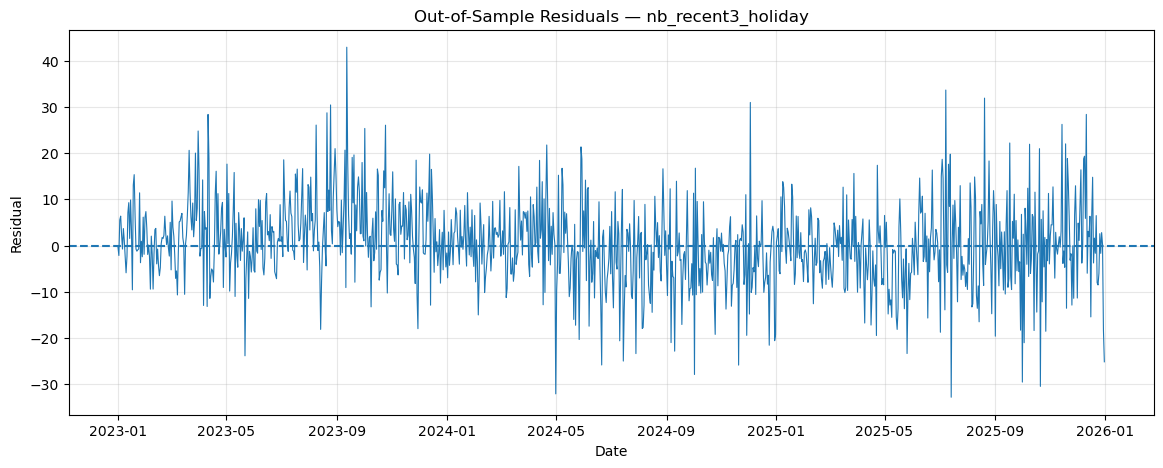

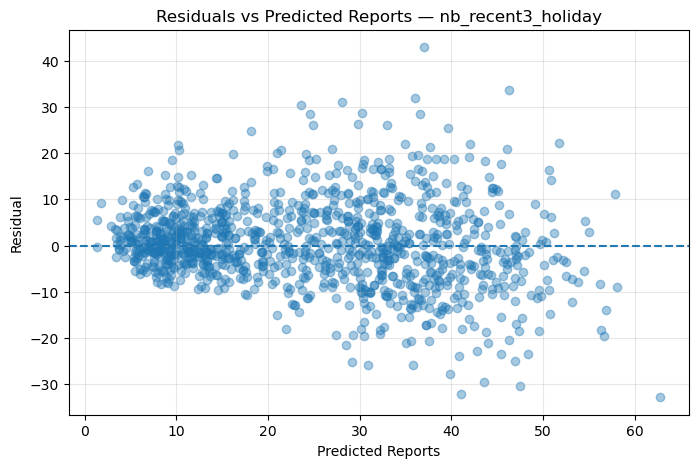

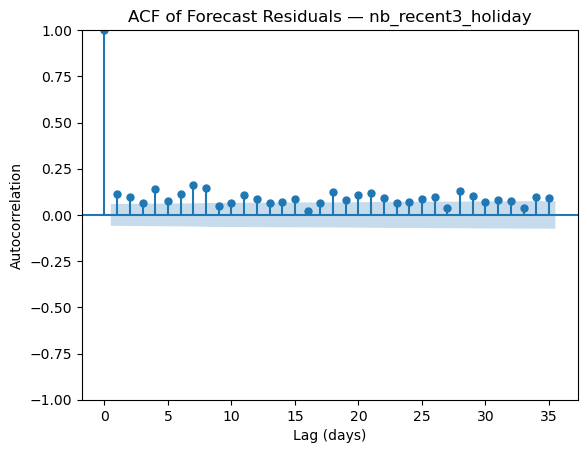

In [9]:
# -----------------------------
# Model definitions
# -----------------------------

BASE_FORMULA = "reports ~ trend_years + C(weekday) + C(month)"

NB_FORMULAS = {
    "nb_base": BASE_FORMULA,
    "nb_lag1": BASE_FORMULA + " + lag1",
    "nb_recent3": BASE_FORMULA + " + recent3_avg",
    "nb_recent3_holiday": BASE_FORMULA + " + recent3_avg + C(is_holiday)",
    "nb_lag1_lag7": BASE_FORMULA + " + lag1 + lag7",
    "nb_4wk": BASE_FORMULA + " + same_weekday_4wk_avg",
    "nb_quadratic": BASE_FORMULA + " + I(trend_years ** 2)",
}

BASELINES = [
    "mean",
    "weekday_mean",
    "lag7",
    "rolling7",
    "same_weekday_4wk",
]

if MODEL_TO_TEST == "all":
    models_to_run = BASELINES + list(NB_FORMULAS.keys())
elif MODEL_TO_TEST == "baselines":
    models_to_run = BASELINES
elif MODEL_TO_TEST in NB_FORMULAS:
    models_to_run = [MODEL_TO_TEST]
else:
    raise ValueError(
        "Unknown MODEL_TO_TEST. Choose 'all', 'baselines', "
        + ", ".join(repr(x) for x in NB_FORMULAS)
    )

results = []
oos_predictions = []

# -----------------------------
# Expanding-window validation
# -----------------------------

for test_year in TEST_YEARS:

    train = daily_df[
        daily_df["reported"].dt.year < test_year
    ].copy()

    test = daily_df[
        daily_df["reported"].dt.year == test_year
    ].copy()

    for model_name in models_to_run:

        pred = None
        alpha = np.nan

        # ----- Simple baselines -----
        if model_name == "mean":
            pred = pd.Series(train["reports"].mean(), index=test.index)

        elif model_name == "weekday_mean":
            weekday_means = train.groupby("weekday")["reports"].mean()
            pred = test["weekday"].map(weekday_means)

        elif model_name == "lag7":
            pred = test["lag7"]

        elif model_name == "rolling7":
            pred = test["rolling7_avg"]

        elif model_name == "same_weekday_4wk":
            pred = test["same_weekday_4wk_avg"]

        # ----- Negative Binomial models -----
        else:
            formula = NB_FORMULAS[model_name]

            required_cols = []
            for col in ["lag1", "lag7", "recent3_avg", "same_weekday_4wk_avg"]:
                if col in formula:
                    required_cols.append(col)

            train_fit = train.dropna(subset=required_cols).copy()
            test_fit = test.dropna(subset=required_cols).copy()

            # Suppress optimizer RuntimeWarnings while still allowing
            # convergence failures to surface as actual exceptions.
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=RuntimeWarning)

                nb_model = smf.negativebinomial(
                    formula,
                    data=train_fit
                ).fit(maxiter=300, disp=False)

            pred = pd.Series(
                nb_model.predict(test_fit),
                index=test_fit.index
            )
            alpha = nb_model.params.get("alpha", np.nan)

        # Keep only rows where both actual and predicted values exist.
        valid_idx = test.index.intersection(pred.dropna().index)
        actual = test.loc[valid_idx, "reports"]
        predicted = pred.loc[valid_idx]

        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))

        results.append({
            "Test Year": test_year,
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "Alpha": alpha,
            "N": len(valid_idx)
        })

        for idx in valid_idx:
            oos_predictions.append({
                "reported": test.loc[idx, "reported"],
                "reports": test.loc[idx, "reports"],
                "weekday": test.loc[idx, "weekday"],
                "month": test.loc[idx, "month"],
                "Model": model_name,
                "prediction": float(pred.loc[idx]),
                "Test Year": test_year
            })

# -----------------------------
# Performance tables
# -----------------------------

results_df = pd.DataFrame(results)

print("YEAR-BY-YEAR PERFORMANCE")
display(
    results_df[
        ["Test Year", "Model", "MAE", "RMSE", "Alpha", "N"]
    ].round(3)
)

average_results = (
    results_df
    .groupby("Model", as_index=False)
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_Alpha=("Alpha", "mean")
    )
    .sort_values("Mean_MAE")
)

print("\nAVERAGE PERFORMANCE ACROSS TEST YEARS")
display(average_results.round(3))

best_model = average_results.iloc[0]["Model"]
best_mae = average_results.iloc[0]["Mean_MAE"]

print(f"\nBest average MAE: {best_model} -> {best_mae:.3f}")

# -----------------------------
# Diagnostics for a single NB model
# -----------------------------

if len(models_to_run) == 1 and models_to_run[0] in NB_FORMULAS:

    selected_model = models_to_run[0]

    diagnostics = pd.DataFrame(oos_predictions)
    diagnostics = diagnostics[
        diagnostics["Model"] == selected_model
    ].sort_values("reported").copy()

    diagnostics["residual"] = (
        diagnostics["reports"] - diagnostics["prediction"]
    )
    diagnostics["absolute_error"] = diagnostics["residual"].abs()

    print("\nOUT-OF-SAMPLE DIAGNOSTICS")
    print(f"Mean residual (bias): {diagnostics['residual'].mean():.3f}")

    weekday_order = [
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ]

    print("\nMAE by weekday:")
    display(
        diagnostics.groupby("weekday")["absolute_error"]
        .mean()
        .reindex(weekday_order)
        .round(3)
        .to_frame("MAE")
    )

    print("\nMean residual by weekday:")
    display(
        diagnostics.groupby("weekday")["residual"]
        .mean()
        .reindex(weekday_order)
        .round(3)
        .to_frame("Mean residual")
    )

    print("\nMAE by month:")
    display(
        diagnostics.groupby("month")["absolute_error"]
        .mean()
        .round(3)
        .to_frame("MAE")
    )

    # Residuals through time
    plt.figure(figsize=(14, 5))
    plt.plot(
        diagnostics["reported"],
        diagnostics["residual"],
        linewidth=0.8
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.title(f"Out-of-Sample Residuals — {selected_model}")
    plt.grid(alpha=0.3)
    plt.show()

    # Residuals vs predictions
    plt.figure(figsize=(8, 5))
    plt.scatter(
        diagnostics["prediction"],
        diagnostics["residual"],
        alpha=0.4
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Reports")
    plt.ylabel("Residual")
    plt.title(f"Residuals vs Predicted Reports — {selected_model}")
    plt.grid(alpha=0.3)
    plt.show()

    # Residual ACF
    plot_acf(diagnostics["residual"], lags=35)
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.title(f"ACF of Forecast Residuals — {selected_model}")
    plt.show()


## 5. How to use this notebook

A practical workflow is:

1. Run the notebook from the top once.
2. Set `MODEL_TO_TEST = "all"` and compare average MAE/RMSE.
3. Set `MODEL_TO_TEST` to one specific NB model and rerun the testing cell to inspect its residual diagnostics.
4. Keep a new feature/model only if it improves **out-of-sample** performance consistently enough to justify the added complexity.

For the current project, MAE is particularly interpretable: an MAE of 7.6 means the forecast misses the actual daily report count by about 7.6 reports on average.
